# Predictive Modeling for Course Demand and Revenue Forecasting on EduPro

## Internship Project

Prepared by:
Navyareddy Boddu

Dataset:
EduPro Online Platform.xlsx

In [2]:
# Importing the Pandas library
import pandas as pd

In [3]:
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

In [4]:
file_path = "../data/EduPro Online Platform.xlsx"

In [5]:
users = pd.read_excel(file_path, sheet_name="Users")

teachers = pd.read_excel(file_path, sheet_name="Teachers")

courses = pd.read_excel(file_path, sheet_name="Courses")

transactions = pd.read_excel(file_path, sheet_name="Transactions")

In [6]:
users.head()


,UserID,UserName,Age,Gender,Email
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com
1,U00002,angela22,29,Female,hallrandy@hotmail.com
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com
3,U00004,fthornton,23,Female,christensencatherine@outlook.com
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com


In [7]:
teachers.head()

,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TC00001,Leonard Montgomery,44,Female,Cybersecurity,6,3.24
1,TC00002,Jill Day,32,Female,Digital Marketing,9,4.14
2,TC00003,Amber Torres,32,Male,Design,4,1.56
3,TC00004,Kristi Scott,34,Female,Machine Learning,9,4.39
4,TC00005,David Williams,34,Male,Finance,2,3.11


In [8]:
courses.head()

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28


In [9]:
courses.head()

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28


In [10]:
users.shape

(3000, 5)

In [11]:
teachers.shape
courses.shape
transactions.shape

(10000, 7)

In [12]:

users.columns

Index(['UserID', 'UserName', 'Age', 'Gender', 'Email'], dtype='str')

In [13]:
teachers.columns

Index(['TeacherID', 'TeacherName', 'Age', 'Gender', 'Expertise',
       'YearsOfExperience', 'TeacherRating'],
      dtype='str')

In [14]:
courses.columns
transactions.columns

Index(['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount',
       'PaymentMethod', 'TeacherID'],
      dtype='str')

In [15]:
courses.columns

Index(['CourseID', 'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel',
       'CoursePrice', 'CourseDuration', 'CourseRating'],
      dtype='str')

In [16]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   UserID    3000 non-null   str  
 1   UserName  3000 non-null   str  
 2   Age       3000 non-null   int64
 3   Gender    3000 non-null   str  
 4   Email     3000 non-null   str  
dtypes: int64(1), str(4)
memory usage: 239.5 KB


In [17]:
teachers.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TeacherID          60 non-null     str    
 1   TeacherName        60 non-null     str    
 2   Age                60 non-null     int64  
 3   Gender             60 non-null     str    
 4   Expertise          60 non-null     str    
 5   YearsOfExperience  60 non-null     int64  
 6   TeacherRating      60 non-null     float64
dtypes: float64(1), int64(2), str(4)
memory usage: 5.7 KB


In [18]:
courses.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CourseID        60 non-null     str    
 1   CourseName      60 non-null     str    
 2   CourseCategory  60 non-null     str    
 3   CourseType      60 non-null     str    
 4   CourseLevel     60 non-null     str    
 5   CoursePrice     60 non-null     float64
 6   CourseDuration  60 non-null     float64
 7   CourseRating    60 non-null     float64
dtypes: float64(3), str(5)
memory usage: 6.9 KB


In [19]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   TransactionID    10000 non-null  str           
 1   UserID           10000 non-null  str           
 2   CourseID         10000 non-null  str           
 3   TransactionDate  10000 non-null  datetime64[us]
 4   Amount           10000 non-null  float64       
 5   PaymentMethod    10000 non-null  str           
 6   TeacherID        10000 non-null  str           
dtypes: datetime64[us](1), float64(1), str(5)
memory usage: 908.0 KB


In [20]:
users.isnull().sum()

UserID      0
UserName    0
Age         0
Gender      0
Email       0
dtype: int64

In [21]:
teachers.isnull().sum()

TeacherID            0
TeacherName          0
Age                  0
Gender               0
Expertise            0
YearsOfExperience    0
TeacherRating        0
dtype: int64

In [22]:
courses.isnull().sum()

CourseID          0
CourseName        0
CourseCategory    0
CourseType        0
CourseLevel       0
CoursePrice       0
CourseDuration    0
CourseRating      0
dtype: int64

In [23]:
transactions.isnull().sum()

TransactionID      0
UserID             0
CourseID           0
TransactionDate    0
Amount             0
PaymentMethod      0
TeacherID          0
dtype: int64

In [24]:
users.duplicated().sum()

np.int64(0)

In [25]:
teachers.duplicated().sum()

np.int64(0)

In [26]:
courses.duplicated().sum()

np.int64(0)

In [27]:
transactions.duplicated().sum()

np.int64(0)

In [28]:
transactions["TransactionDate"] = pd.to_datetime(transactions["TransactionDate"])

In [29]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   TransactionID    10000 non-null  str           
 1   UserID           10000 non-null  str           
 2   CourseID         10000 non-null  str           
 3   TransactionDate  10000 non-null  datetime64[us]
 4   Amount           10000 non-null  float64       
 5   PaymentMethod    10000 non-null  str           
 6   TeacherID        10000 non-null  str           
dtypes: datetime64[us](1), float64(1), str(5)
memory usage: 908.0 KB


In [30]:
courses.describe()

,CoursePrice,CourseDuration,CourseRating
count,60.000000,60.000000,60.000000
mean,92.986333,27.632500,3.097833
std,153.601506,16.092578,1.171232
min,0.000000,1.200000,1.130000
25%,0.000000,14.500000,2.107500
50%,0.000000,28.505000,3.065000
75%,133.615000,43.012500,4.102500
max,490.900000,49.730000,4.940000


In [31]:
data = transactions.merge(courses, on="CourseID")

In [32]:
data = data.merge(teachers, on="TeacherID")

In [33]:
data = data.merge(users, on="UserID")

In [34]:
data.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,CourseName,CourseCategory,CourseType,...,TeacherName,Age_x,Gender_x,Expertise,YearsOfExperience,TeacherRating,UserName,Age_y,Gender_y,Email
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,Digital Marketing,Marketing,Free,...,Kimberly Miller,49,Male,Cybersecurity,24,4.58,morrisonamanda,33,Female,ganderson@yahoo.com
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,Scrum Essentials,Project Management,Free,...,Kimberly Miller,49,Male,Cybersecurity,24,4.58,morrisonamanda,33,Female,ganderson@yahoo.com
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,Content Marketing,Marketing,Free,...,Kimberly Miller,49,Male,Cybersecurity,24,4.58,morrisonamanda,33,Female,ganderson@yahoo.com
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,AI Ethics,Artificial Intelligence,Free,...,Kimberly Miller,49,Male,Cybersecurity,24,4.58,fthornton,23,Female,christensencatherine@outlook.com
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,Content Creation,Digital Marketing,Free,...,Yolanda Levine,49,Female,Machine Learning,21,4.97,fthornton,23,Female,christensencatherine@outlook.com


In [35]:
data.shape

(10000, 24)

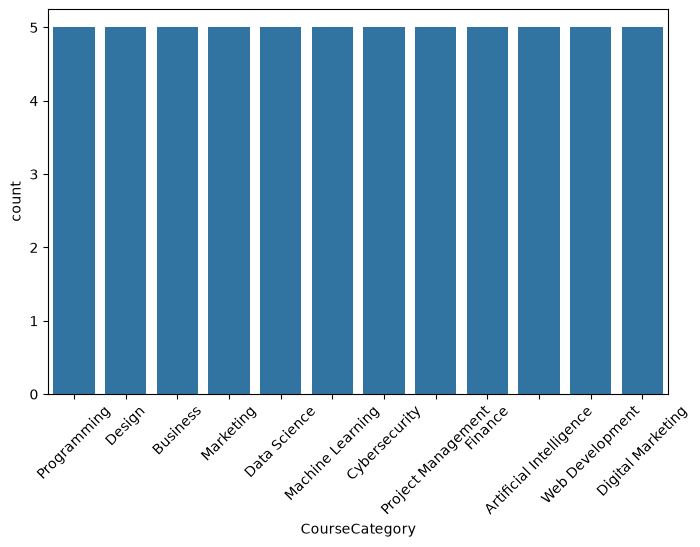

In [36]:
plt.figure(figsize=(8,5))
sns.countplot(data=courses, x="CourseCategory")
plt.xticks(rotation=45)
plt.show()

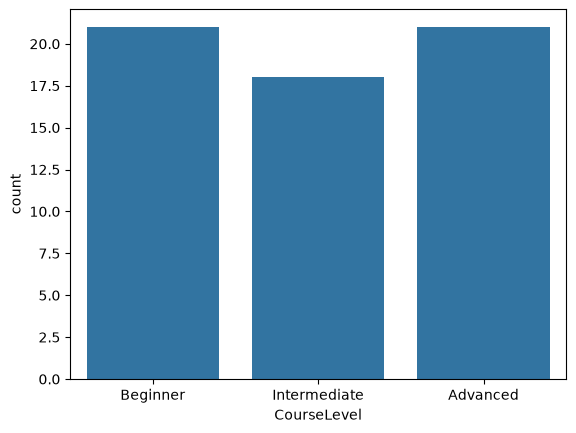

In [37]:
sns.countplot(data=courses, x="CourseLevel")
plt.show()

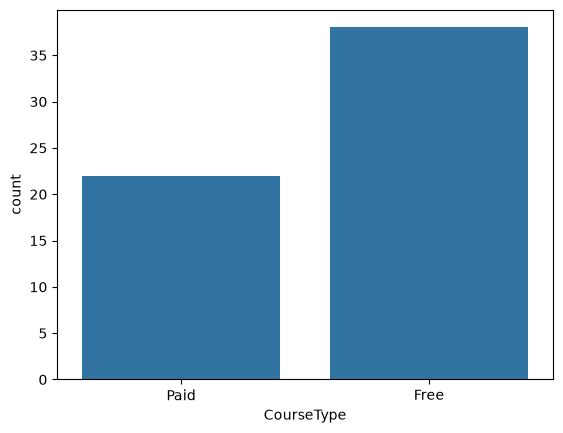

In [38]:
sns.countplot(data=courses, x="CourseType")
plt.show()

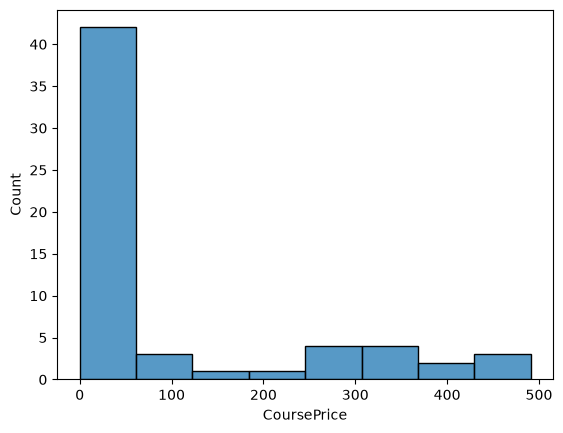

In [39]:
sns.histplot(courses["CoursePrice"])
plt.show()

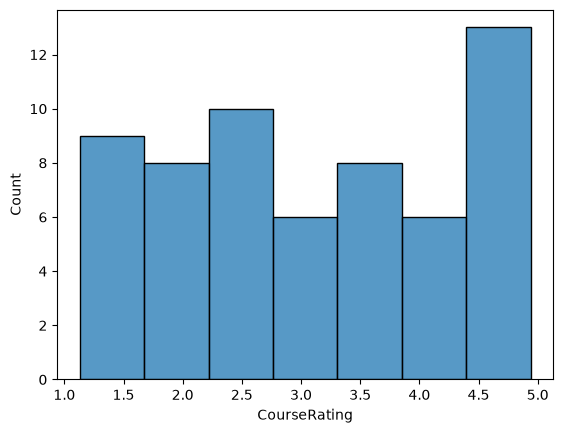

In [40]:
sns.histplot(courses["CourseRating"])
plt.show()

In [41]:
enrollment = data.groupby("CourseID").size().reset_index(name="EnrollmentCount")

In [42]:
revenue = data.groupby("CourseID")["Amount"].sum().reset_index(name="Revenue")

In [43]:
course_data = courses.merge(enrollment, on="CourseID")

In [44]:
course_data = course_data.merge(revenue, on="CourseID")

In [45]:
course_data["PriceBand"] = pd.cut(
    course_data["CoursePrice"],
    bins=[0,500,1000,5000],
    labels=["Low","Medium","High"]
)

In [46]:
course_data["DurationBucket"] = pd.cut(
    course_data["CourseDuration"],
    bins=[0,10,20,40],
    labels=["Short","Medium","Long"]
)

In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [48]:
course_data["CourseCategory"] = le.fit_transform(course_data["CourseCategory"])
course_data["CourseType"] = le.fit_transform(course_data["CourseType"])
course_data["CourseLevel"] = le.fit_transform(course_data["CourseLevel"])
course_data["PriceBand"] = le.fit_transform(course_data["PriceBand"])

In [ ]:
X = course_data[
[
"CourseCategory",
"CourseType",
"CourseLevel",
"CoursePrice",
"CourseDuration",
"CourseRating",
"PriceBand"
]
]

In [57]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

          Feature  Importance
4  CourseDuration    0.357313
5    CourseRating    0.355324
0  CourseCategory    0.153895
2     CourseLevel    0.066316
3     CoursePrice    0.033817
6       PriceBand    0.021560
1      CourseType    0.011775


In [58]:
importance.to_csv("../data/feature_importance.csv", index=False)

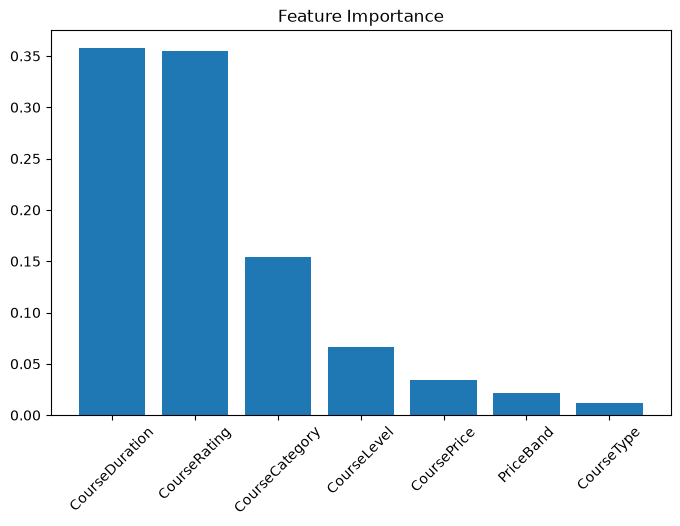

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(importance["Feature"], importance["Importance"])

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

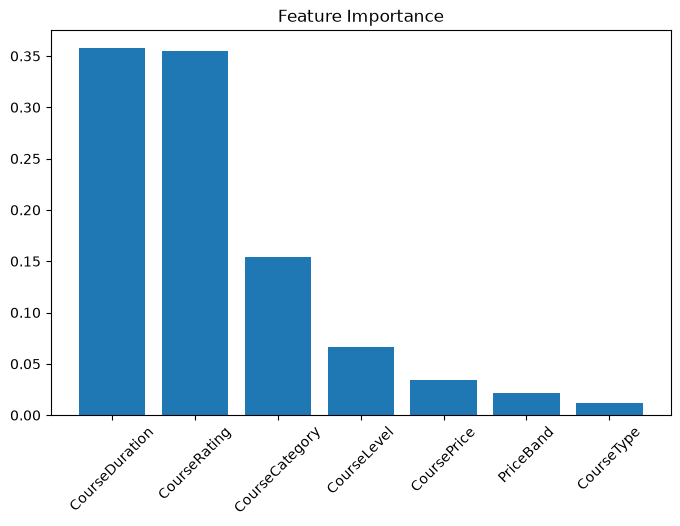

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(importance["Feature"], importance["Importance"])

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

In [50]:
y = course_data["EnrollmentCount"]

In [51]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [52]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)

model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [53]:
pred = model.predict(X_test)

In [54]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

import numpy as np

print("MAE:",mean_absolute_error(y_test,pred))

print("RMSE:",np.sqrt(mean_squared_error(y_test,pred)))

print("R2 Score:",r2_score(y_test,pred))

MAE: 10.525833333333336
RMSE: 12.563259595609201
R2 Score: 0.13382961890243894


In [55]:
importance = pd.DataFrame({
"Feature":X.columns,
"Importance":model.feature_importances_
})

importance.sort_values("Importance",ascending=False)

,Feature,Importance
4,CourseDuration,0.357313
5,CourseRating,0.355324
0,CourseCategory,0.153895
2,CourseLevel,0.066316
3,CoursePrice,0.033817
6,PriceBand,0.021560
1,CourseType,0.011775


In [56]:
import joblib

joblib.dump(model,"../models/enrollment_model.pkl")

['../models/enrollment_model.pkl']